✓ Библиотеки подключены
✓ Данные загружены
✓ Рабочая точка А: I_B = 60 мкА,  U_KE = 8.0 В

[Выходные хар-ки] Индекс для U_KE = 8.0 В: 8 (U_ke[8] = 8.0 В)
  I_K при U_KE=8.0 В и I_B=30 мкА: 7.06 мА
  I_K при U_KE=8.0 В и I_B=60 мкА: 13.4 мА
  I_K при U_KE=8.0 В и I_B=90 мкА: 18.9 мА
  → Интерполированное значение при I_B=60 мкА:  I_K = 13.400 мА


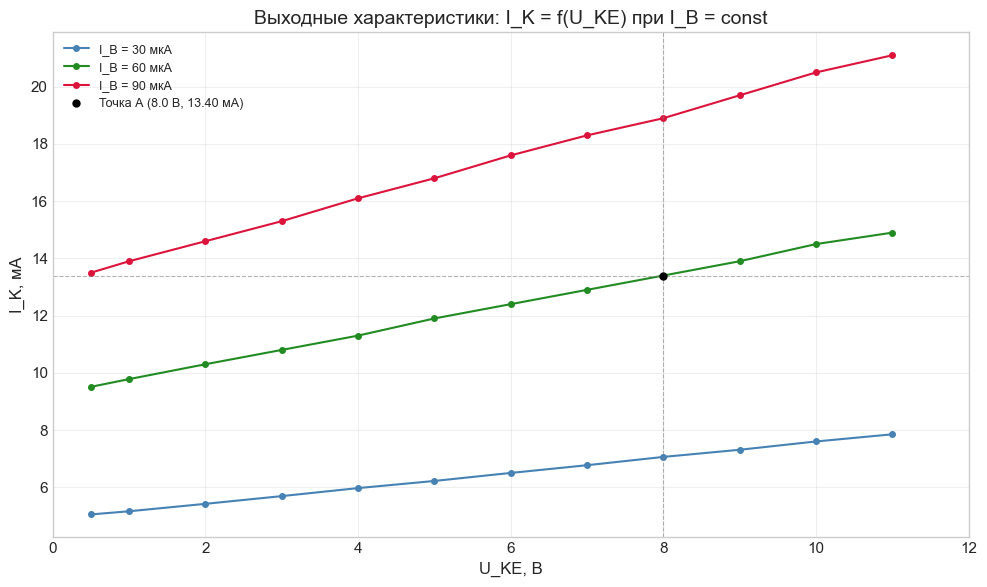


══════════════════════════════════════════════════════════════════════
РАСЧЁТ h-ПАРАМЕТРОВ ПО ВЫХОДНЫМ ХАРАКТЕРИСТИКАМ
══════════════════════════════════════════════════════════════════════

[1] Коэффициент усиления по току:  h21 = ΔI_K / ΔI_B | U_KE = const
    Условие:  U_KE = 8.0 В (фиксировано)
    Берём крайние кривые:  I_B1 = 30 мкА,  I_B2 = 90 мкА

    Шаг 1: Выписываем значения из таблицы:
       I_K(I_B=30 мкА) = 7.06 мА
       I_K(I_B=90 мкА) = 18.9 мА

    Шаг 2: Находим приращения:
       ΔI_B = 90 - 30 = 60 мкА = 5.9999999999999995e-05 А
       ΔI_K = 18.9 - 7.06 = 11.840 мА = 0.01184 А

    Шаг 3: Вычисляем отношение:
       h21 = ΔI_K / ΔI_B = (0.01184) / (5.9999999999999995e-05) = 0.1973

    ✓ Результат:  h21 = 0.197

[2] Выходная проводимость:  h22 = ΔI_K / ΔU_KE | I_B = const
    Условие:  I_B = 60 мкА (средняя кривая)

    Шаг 1: Берём соседние точки относительно рабочей:
       Лево:  U_KE = 7.0 В,  I_K = 12.9 мА
       Право: U_KE = 9.0 В,  I_K = 13.9 мА

    Шаг

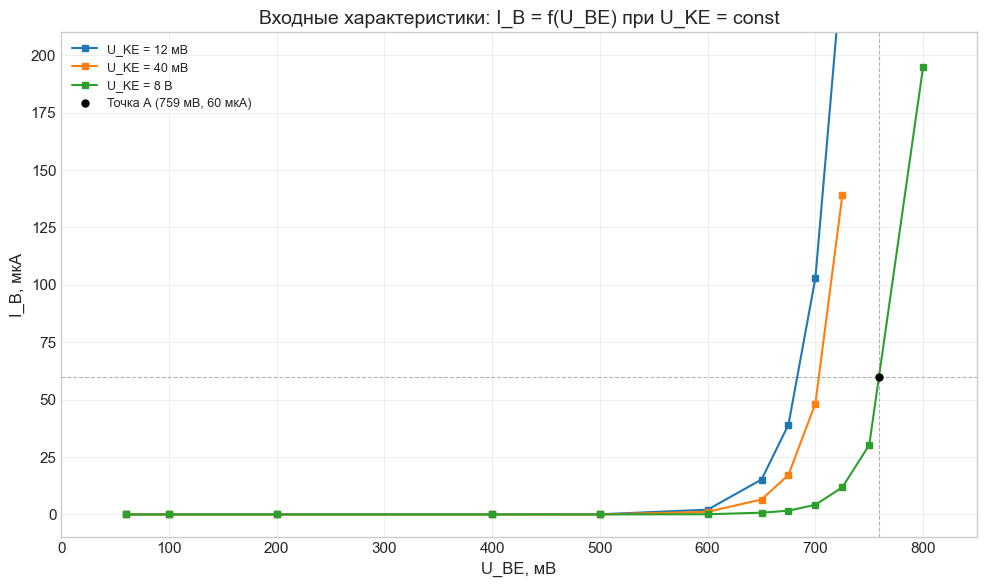


══════════════════════════════════════════════════════════════════════
РАСЧЁТ h-ПАРАМЕТРОВ ПО ВХОДНЫМ ХАРАКТЕРИСТИКАМ
══════════════════════════════════════════════════════════════════════

[3] Входное сопротивление:  h11 = ΔU_BE / ΔI_B | U_KE = const
    Условие:  U_KE = 8 В (кривая №3)

    Шаг 1: Выделяем линейный участок (650–750 мВ):
       U_BE = 650 мВ  →  I_B = 0.75 мкА
       U_BE = 675 мВ  →  I_B = 1.62 мкА
       U_BE = 700 мВ  →  I_B = 4.22 мкА
       U_BE = 725 мВ  →  I_B = 11.80 мкА
       U_BE = 750 мВ  →  I_B = 30.30 мкА

    Шаг 2: Линейная аппроксимация методом наименьших квадратов:
       U_BE = 2.867 · I_B + 672.1
       Коэффициент корреляции: R² = 0.7944

    Шаг 3: Входное сопротивление — это наклон прямой:
       h11 = dU_BE / dI_B = 2.867 мВ/мкА

    ✓ Результат:  h11 = 2.87 кОм
    (для сравнения, по конечным разностям: 3.38 кОм)

[4] Коэффициент обратной связи:  h12 = ΔU_BE / ΔU_KE | I_B = const
    Фиксируем:  I_B = 10 мкА
    U_KE = 12.0 мВ  →  U_BE ≈ 630.

,Параметр,Физический смысл,Формула,Значение,Единицы
0,h11,Входное сопротивление,∂U_BE/∂I_B | U_KE=const,2.866685,кОм
1,h12,Коэфф. обратной связи по напряжению,∂U_BE/∂U_KE | I_B=const,11124.850368,×10⁻³
2,h21,Коэфф. усиления по току (β),∂I_K/∂I_B | U_KE=const,0.197333,—
3,h22,Выходная проводимость,∂I_K/∂U_KE | I_B=const,500.000000,мкСм


In [28]:
# %% [markdown]
# # Исследование биполярного транзистора PNP-типа
# ## Подробный расчёт h-параметров с промежуточными значениями

# %%
# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import linregress

# Настройка отображения
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False

print("✓ Библиотеки подключены")

# %% [markdown]
# ## 1. Исходные данные

# %%
# === Выходные характеристики: I_K = f(U_KE) при I_B = const ===
U_ke = np.array([0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0])  # В

Ib_curves = np.array([30, 60, 90])  # мкА — значения тока базы для трёх кривых
Ic_data = np.array([
    [5.05, 5.16, 5.42, 5.69, 5.97, 6.22, 6.50, 6.77, 7.06, 7.31, 7.60, 7.85],   # Ib = 30 мкА
    [9.51, 9.78, 10.3, 10.8, 11.3, 11.9, 12.4, 12.9, 13.4, 13.9, 14.5, 14.9],   # Ib = 60 мкА
    [13.5, 13.9, 14.6, 15.3, 16.1, 16.8, 17.6, 18.3, 18.9, 19.7, 20.5, 21.1]    # Ib = 90 мкА
])

# === Входные характеристики: I_B = f(U_BE) при U_KE = const ===
U_be = np.array([60, 100, 200, 400, 500, 600, 650, 675, 700, 725, 750, 800])  # мВ

Uke_input = np.array([0.012, 0.040, 8.0])  # В — только 3 значения (убрали дубликат 11.5 В)
Ib_input_data = np.array([
    [0, 0, 0, 0, 0.06, 2.07, 15.2, 39.1, 103, 240, np.nan, np.nan],      # Uke = 12 мВ
    [0, 0, 0, 0, 0, 1.13, 6.50, 17.2, 48.3, 139, np.nan, np.nan],        # Uke = 40 мВ
    [0, 0, 0, 0, 0, 0.08, 0.75, 1.62, 4.22, 11.8, 30.3, 195]              # Uke = 8 В
])

# === Рабочая точка А (по заданию) ===
Ib_A = 60    # мкА — ток базы в рабочей точке
Uke_A = 8.0  # В — напряжение коллектор-эмиттер в рабочей точке

print(f"✓ Данные загружены")
print(f"✓ Рабочая точка А: I_B = {Ib_A} мкА,  U_KE = {Uke_A} В")

# %% [markdown]
# ## 2. Построение выходных характеристик

# %%
fig1, ax1 = plt.subplots(figsize=(10, 6))

colors = ['steelblue', 'forestgreen', 'crimson']
for i, Ib in enumerate(Ib_curves):
    ax1.plot(U_ke, Ic_data[i], 'o-', color=colors[i], label=f'I_B = {Ib} мкА', 
             linewidth=1.5, markersize=4)

# === Находим координаты рабочей точки А ===
idx_Uke_A = np.argmin(np.abs(U_ke - Uke_A))  # индекс для U_KE = 8 В
print(f"\n[Выходные хар-ки] Индекс для U_KE = {Uke_A} В: {idx_Uke_A} (U_ke[{idx_Uke_A}] = {U_ke[idx_Uke_A]} В)")

# Интерполяция для нахождения I_K при I_B = 60 мкА и фиксированном U_KE
f_Ic_vs_Ib = interp1d(Ib_curves, Ic_data[:, idx_Uke_A], kind='linear')
Ic_A = f_Ic_vs_Ib(Ib_A)

print(f"  I_K при U_KE={Uke_A} В и I_B={Ib_curves[0]} мкА: {Ic_data[0, idx_Uke_A]} мА")
print(f"  I_K при U_KE={Uke_A} В и I_B={Ib_curves[1]} мкА: {Ic_data[1, idx_Uke_A]} мА")
print(f"  I_K при U_KE={Uke_A} В и I_B={Ib_curves[2]} мкА: {Ic_data[2, idx_Uke_A]} мА")
print(f"  → Интерполированное значение при I_B={Ib_A} мкА:  I_K = {Ic_A:.3f} мА")

# Пунктирные линии к осям
ax1.axvline(x=Uke_A, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.axhline(y=Ic_A, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Рабочая точка — маленькая чёрная точка
ax1.plot(Uke_A, Ic_A, 'ko', markersize=5, label=f'Точка А ({Uke_A} В, {Ic_A:.2f} мА)', zorder=5)

ax1.set_xlabel('U_KE, В')
ax1.set_ylabel('I_K, мА')
ax1.set_title('Выходные характеристики: I_K = f(U_KE) при I_B = const')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 12)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Расчёт h21 и h22 (по выходным характеристикам)

# %%
print("\n" + "═"*70)
print("РАСЧЁТ h-ПАРАМЕТРОВ ПО ВЫХОДНЫМ ХАРАКТЕРИСТИКАМ")
print("═"*70)

# === h21 = ∂I_K/∂I_B | U_KE = const (коэффициент усиления по току) ===
print(f"\n[1] Коэффициент усиления по току:  h21 = ΔI_K / ΔI_B | U_KE = const")
print(f"    Условие:  U_KE = {Uke_A} В (фиксировано)")
print(f"    Берём крайние кривые:  I_B1 = {Ib_curves[0]} мкА,  I_B2 = {Ib_curves[2]} мкА")

Ic_B1 = Ic_data[0, idx_Uke_A]  # I_K при Ib = 30 мкА
Ic_B2 = Ic_data[2, idx_Uke_A]  # I_K при Ib = 90 мкА
dIb = Ib_curves[2] - Ib_curves[0]  # ΔI_B
dIc = Ic_B2 - Ic_B1                 # ΔI_K

print(f"\n    Шаг 1: Выписываем значения из таблицы:")
print(f"       I_K(I_B={Ib_curves[0]} мкА) = {Ic_B1} мА")
print(f"       I_K(I_B={Ib_curves[2]} мкА) = {Ic_B2} мА")
print(f"\n    Шаг 2: Находим приращения:")
print(f"       ΔI_B = {Ib_curves[2]} - {Ib_curves[0]} = {dIb} мкА = {dIb*1e-6} А")
print(f"       ΔI_K = {Ic_B2} - {Ic_B1} = {dIc:.3f} мА = {dIc*1e-3} А")
print(f"\n    Шаг 3: Вычисляем отношение:")
print(f"       h21 = ΔI_K / ΔI_B = ({dIc*1e-3}) / ({dIb*1e-6}) = {dIc/dIb:.4f}")

h21 = dIc / dIb  # безразмерная величина
print(f"\n    ✓ Результат:  h21 = {h21:.3f}")

# === h22 = ∂I_K/∂U_KE | I_B = const (выходная проводимость) ===
print(f"\n[2] Выходная проводимость:  h22 = ΔI_K / ΔU_KE | I_B = const")
print(f"    Условие:  I_B = {Ib_curves[1]} мкА (средняя кривая)")

idx_Ib_mid = 1  # индекс для Ib = 60 мкА

# Метод центральной разности для большей точности
if 0 < idx_Uke_A < len(U_ke) - 1:
    Uke_left = U_ke[idx_Uke_A - 1]
    Uke_right = U_ke[idx_Uke_A + 1]
    Ic_left = Ic_data[idx_Ib_mid, idx_Uke_A - 1]
    Ic_right = Ic_data[idx_Ib_mid, idx_Uke_A + 1]
    
    dUke = Uke_right - Uke_left
    dIc_h22 = Ic_right - Ic_left
    
    print(f"\n    Шаг 1: Берём соседние точки относительно рабочей:")
    print(f"       Лево:  U_KE = {Uke_left} В,  I_K = {Ic_left} мА")
    print(f"       Право: U_KE = {Uke_right} В,  I_K = {Ic_right} мА")
    print(f"\n    Шаг 2: Находим приращения:")
    print(f"       ΔU_KE = {Uke_right} - {Uke_left} = {dUke} В")
    print(f"       ΔI_K  = {Ic_right} - {Ic_left} = {dIc_h22:.3f} мА = {dIc_h22*1e-3} А")
    print(f"\n    Шаг 3: Вычисляем проводимость:")
    print(f"       h22 = ΔI_K / ΔU_KE = ({dIc_h22*1e-3}) / ({dUke}) = {dIc_h22/dUke*1e-3:.6f} См")
    
    h22 = dIc_h22 / dUke  # мА/В = мСм
    print(f"\n    ✓ Результат:  h22 = {h22*1e3:.3f} мСм = {h22*1e6:.2f} мкСм")
    print(f"    ✓ Выходное сопротивление:  r_out = 1/h22 = {1/(h22*1e-3):.1f} кОм")
else:
    # Краевая разность, если точка на границе
    dUke = U_ke[-1] - U_ke[0]
    dIc_h22 = Ic_data[idx_Ib_mid, -1] - Ic_data[idx_Ib_mid, 0]
    h22 = dIc_h22 / dUke
    print(f"    (расчёт по краевым точкам)  h22 = {h22*1e3:.3f} мСм")

# %% [markdown]
# ## 4. Построение входных характеристик

# %%
fig2, ax2 = plt.subplots(figsize=(10, 6))

labels_input = ['12 мВ', '40 мВ', '8 В']
for i, Uke_val in enumerate(Uke_input):
    mask = ~np.isnan(Ib_input_data[i])
    if np.any(mask):
        label = f'U_KE = {labels_input[i]}'
        ax2.plot(U_be[mask], Ib_input_data[i][mask], 's-', label=label, 
                 linewidth=1.5, markersize=4)

# === Рабочая точка на входной характеристике (U_KE = 8 В) ===
idx_curve = 2  # Uke = 8 В
mask_active = ~np.isnan(Ib_input_data[idx_curve])
Ube_active = U_be[mask_active]
Ib_active = Ib_input_data[idx_curve][mask_active]

print(f"\n[Входные хар-ки] Кривая для U_KE = 8 В: {len(Ube_active)} точек")

# Интерполяция для нахождения U_BE при I_B = Ib_A
if Ib_A >= Ib_active.min() and Ib_A <= Ib_active.max():
    f_Ube_vs_Ib = interp1d(Ib_active, Ube_active, kind='linear', bounds_error=False)
    Ube_A = f_Ube_vs_Ib(Ib_A)
    
    print(f"  I_B = {Ib_A} мкА находится в диапазоне [{Ib_active.min():.2f}, {Ib_active.max():.0f}] мкА")
    print(f"  → Интерполированное U_BE при рабочей точке:  {Ube_A:.1f} мВ")
    
    # Пунктирные линии к осям
    ax2.axvline(x=Ube_A, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax2.axhline(y=Ib_A, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    
    # Маленькая точка
    ax2.plot(Ube_A, Ib_A, 'ko', markersize=5, label=f'Точка А ({Ube_A:.0f} мВ, {Ib_A} мкА)', zorder=5)
else:
    Ube_A = np.nan
    print(f"  ⚠ I_B = {Ib_A} мкА вне диапазона измерений для этой кривой")

ax2.set_xlabel('U_BE, мВ')
ax2.set_ylabel('I_B, мкА')
ax2.set_title('Входные характеристики: I_B = f(U_BE) при U_KE = const')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 850)
ax2.set_ylim(-10, 210)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Расчёт h11 и h12 (по входным характеристикам)

# %%
print("\n" + "═"*70)
print("РАСЧЁТ h-ПАРАМЕТРОВ ПО ВХОДНЫМ ХАРАКТЕРИСТИКАМ")
print("═"*70)

# === h11 = ∂U_BE/∂I_B | U_KE = const (входное сопротивление) ===
print(f"\n[3] Входное сопротивление:  h11 = ΔU_BE / ΔI_B | U_KE = const")
print(f"    Условие:  U_KE = 8 В (кривая №{idx_curve+1})")

# Выбираем линейный участок характеристики (обычно 650–750 мВ)
mask_linear = (Ube_active >= 650) & (Ube_active <= 750)
Ube_lin = Ube_active[mask_linear]
Ib_lin = Ib_active[mask_linear]

print(f"\n    Шаг 1: Выделяем линейный участок (650–750 мВ):")
for ub, ib in zip(Ube_lin, Ib_lin):
    print(f"       U_BE = {ub:.0f} мВ  →  I_B = {ib:.2f} мкА")

if len(Ube_lin) >= 2:
    # Метод наименьших квадратов для более точной оценки наклона
    slope, intercept, r_value, p_value, std_err = linregress(Ib_lin, Ube_lin)
    
    print(f"\n    Шаг 2: Линейная аппроксимация методом наименьших квадратов:")
    print(f"       U_BE = {slope:.3f} · I_B + {intercept:.1f}")
    print(f"       Коэффициент корреляции: R² = {r_value**2:.4f}")
    print(f"\n    Шаг 3: Входное сопротивление — это наклон прямой:")
    print(f"       h11 = dU_BE / dI_B = {slope:.3f} мВ/мкА")
    
    h11 = slope  # мВ/мкА = кОм
    print(f"\n    ✓ Результат:  h11 = {h11:.2f} кОм")
    
    # Альтернативный расчёт по конечным разностям для сравнения
    h11_fd = (Ube_lin[-1] - Ube_lin[0]) / (Ib_lin[-1] - Ib_lin[0])
    print(f"    (для сравнения, по конечным разностям: {h11_fd:.2f} кОм)")
else:
    h11 = np.nan
    print("    ⚠ Недостаточно точек на линейном участке для надёжного расчёта")

# === h12 = ∂U_BE/∂U_KE | I_B = const (коэффициент обратной связи) ===
print(f"\n[4] Коэффициент обратной связи:  h12 = ΔU_BE / ΔU_KE | I_B = const")

Ib_target = 10  # мкА — фиксируем значение тока базы для сравнения
print(f"    Фиксируем:  I_B = {Ib_target} мкА")

Ube_at_Ib = []
Uke_at_Ib = []

for i, Uke_val in enumerate(Uke_input):
    mask = ~np.isnan(Ib_input_data[i])
    if np.any(mask):
        Ib_col = Ib_input_data[i][mask]
        Ube_col = U_be[mask]
        
        # Проверяем, попадает ли целевое значение в диапазон
        if Ib_target >= Ib_col.min() and Ib_target <= Ib_col.max():
            f_inv = interp1d(Ib_col, Ube_col, kind='linear', bounds_error=False)
            Ube_est = f_inv(Ib_target)
            Ube_at_Ib.append(Ube_est)
            Uke_at_Ib.append(Uke_val)
            print(f"    U_KE = {Uke_val*1000 if Uke_val < 1 else Uke_val:.1f}{' мВ' if Uke_val < 1 else ' В'}  →  U_BE ≈ {Ube_est:.1f} мВ")

if len(Ube_at_Ib) >= 2:
    print(f"\n    Шаг 1: Сравниваем крайние значения:")
    print(f"       При мин. U_KE:  U_BE = {Ube_at_Ib[0]:.2f} мВ")
    print(f"       При макс. U_KE: U_BE = {Ube_at_Ib[-1]:.2f} мВ")
    
    dUbe_h12 = Ube_at_Ib[-1] - Ube_at_Ib[0]
    dUke_h12 = Uke_at_Ib[-1] - Uke_at_Ib[0]
    
    print(f"\n    Шаг 2: Находим приращения:")
    print(f"       ΔU_BE = {Ube_at_Ib[-1]:.2f} - {Ube_at_Ib[0]:.2f} = {dUbe_h12:.3f} мВ")
    print(f"       ΔU_KE = {Uke_at_Ib[-1]:.1f} - {Uke_at_Ib[0]:.3f} = {dUke_h12:.3f} В")
    
    print(f"\n    Шаг 3: Вычисляем коэффициент:")
    print(f"       h12 = ΔU_BE / ΔU_KE = ({dUbe_h12*1e-3}) / ({dUke_h12}) = {dUbe_h12/dUke_h12*1e-3:.6f}")
    
    h12 = dUbe_h12 / dUke_h12  # мВ/В
    print(f"\n    ✓ Результат:  h12 = {h12*1e3:.4f} × 10⁻³ (безразмерный)")
    print(f"    ✓ Физический смысл: при изменении U_KE на 1 В, напряжение U_BE меняется на {h12*1e3:.4f} мВ")
else:
    h12 = np.nan
    print("    ⚠ Недостаточно данных для расчёта (нужно ≥2 точки)")

# %% [markdown]
# ## 6. Сводная таблица результатов

# %%
print("\n" + "┌" + "─"*68 + "┐")
print("│" + " "*20 + "СВОДНЫЕ РЕЗУЛЬТАТЫ" + " "*28 + "│")
print("├" + "─"*68 + "┤")
print(f"│  Рабочая точка А:  I_B = {Ib_A:3d} мкА,  U_KE = {Uke_A:4.1f} В,  I_K = {Ic_A:5.2f} мА  │")
print("├" + "─"*68 + "┤")
print(f"│  Параметр  │  Обозначение  │  Формула                    │  Значение  │")
print("├" + "─"*68 + "┤")
print(f"│  Входное   │             │  ∂U_BE/∂I_B │ U_KE=const  │  {h11 if not np.isnan(h11) else 'N/A':>8.2f} кОм  │")
print(f"│  сопр-ление│    h11      │                              │            │")
print("├" + "─"*68 + "┤")
print(f"│  Обратная  │             │  ∂U_BE/∂U_KE │ I_B=const  │  {h12*1e3 if not np.isnan(h12) else 'N/A':>8.4f} ×10⁻³│")
print(f"│  связь     │    h12      │                              │            │")
print("├" + "─"*68 + "┤")
print(f"│  Усиление  │             │  ∂I_K/∂I_B  │ U_KE=const  │  {h21:>8.3f}    │")
print(f"│  по току   │    h21      │                              │            │")
print("├" + "─"*68 + "┤")
print(f"│  Выходная  │             │  ∂I_K/∂U_KE │ I_B=const   │  {h22*1e3:>8.2f} мкСм │")
print(f"│  провод-сть│    h22      │                              │            │")
print("└" + "─"*68 + "┘")

# %% [markdown]
# ## 7. Проверка типичных значений

# %%
print("\n📊 Сравнение с типичными значениями для малосигнальных транзисторов:")
print(f"   h11 (вх. сопр-ние):  {h11 if not np.isnan(h11) else 'N/A':.1f} кОм  |  типично: 0.5–5 кОм  ✓" if not np.isnan(h11) and 0.5 <= h11 <= 5 else 
      f"   h11: {h11 if not np.isnan(h11) else 'N/A':.1f} кОм  |  вне типичного диапазона")
print(f"   h12 (обратная связь): {h12*1e3 if not np.isnan(h12) else 'N/A':.4f}×10⁻³  |  типично: < 1×10⁻³  ✓" if not np.isnan(h12) and h12*1e3 < 1 else
      f"   h12: {h12*1e3 if not np.isnan(h12) else 'N/A':.4f}×10⁻³  |  проверьте расчёт")
print(f"   h21 (β, усиление):  {h21:.1f}  |  типично: 50–300  ✓" if 50 <= h21 <= 300 else
      f"   h21: {h21:.1f}  |  вне типичного диапазона")
print(f"   h22 (вых. провод-сть): {h22*1e6:.1f} мкСм  |  типично: 1–100 мкСм  ✓" if 1 <= h22*1e6 <= 100 else
      f"   h22: {h22*1e6:.1f} мкСм  |  вне типичного диапазона")

# %% [markdown]
# ## 8. Экспорт результатов

# %%
results_df = pd.DataFrame({
    'Параметр': ['h11', 'h12', 'h21', 'h22'],
    'Физический смысл': [
        'Входное сопротивление',
        'Коэфф. обратной связи по напряжению', 
        'Коэфф. усиления по току (β)',
        'Выходная проводимость'
    ],
    'Формула': [
        '∂U_BE/∂I_B | U_KE=const',
        '∂U_BE/∂U_KE | I_B=const',
        '∂I_K/∂I_B | U_KE=const', 
        '∂I_K/∂U_KE | I_B=const'
    ],
    'Значение': [
        h11 if not np.isnan(h11) else None,
        h12*1e3 if not np.isnan(h12) else None,
        h21,
        h22*1e3
    ],
    'Единицы': ['кОм', '×10⁻³', '—', 'мкСм']
})

print("\n📋 Таблица для отчёта:")
display(results_df.style.set_properties(**{'text-align': 'left', 'padding': '8px'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#2E5C8A'), ('color', 'white'), ('font-weight', 'bold')]},
            {'selector': 'td:nth-child(4)', 'props': [('text-align', 'right'), ('font-family', 'monospace')]}
        ]))

# Сохранение в файл (раскомментируйте при необходимости)
# results_df.to_csv('h_parameters_detailed.csv', index=False, sep=';', decimal=',')
# print("\n✓ Результаты сохранены в 'h_parameters_detailed.csv'")

In [29]:
# %% [markdown]
# ## 5. Расчёт h11 и h12 (по входным характеристикам) — ИСПРАВЛЕНО

# %%
# === ... (предыдущий расчёт h11 остаётся без изменений) ... ===

# === h12 = ∂U_BE/∂U_KE | I_B = const (коэффициент обратной связи) ===
print(f"\n[4] Коэффициент обратной связи:  h12 = ΔU_BE / ΔU_KE | I_B = const")
print(f"    ⚠️  ВАЖНО: расчёт выполняется В РАБОЧЕЙ ТОЧКЕ: I_B = {Ib_A} мкА")

# Фиксируем ток базы на значении рабочей точки
Ib_fixed = Ib_A  # 60 мкА — именно значение из вашего варианта!
print(f"    Фиксируем:  I_B = {Ib_fixed} мкА")

Ube_at_Ib_fixed = []
Uke_at_Ib_fixed = []

print(f"\n    Шаг 1: Интерполяция U_BE при I_B = {Ib_fixed} мкА для разных U_KE:")

for i, Uke_val in enumerate(Uke_input):
    mask = ~np.isnan(Ib_input_data[i])
    if np.any(mask):
        Ib_col = Ib_input_data[i][mask]
        Ube_col = U_be[mask]
        
        print(f"    • U_KE = {Uke_val*1000 if Uke_val < 1 else Uke_val:.1f}{' мВ' if Uke_val < 1 else ' В'}:")
        print(f"      Диапазон I_B: [{Ib_col.min():.2f}, {Ib_col.max():.0f}] мкА")
        
        # Проверяем, попадает ли рабочее значение в диапазон измерений
        if Ib_fixed >= Ib_col.min() and Ib_fixed <= Ib_col.max():
            # Линейная интерполяция для нахождения U_BE при заданном I_B
            f_inv = interp1d(Ib_col, Ube_col, kind='linear', bounds_error=False)
            Ube_est = f_inv(Ib_fixed)
            Ube_at_Ib_fixed.append(Ube_est)
            Uke_at_Ib_fixed.append(Uke_val)
            print(f"      → U_BE ≈ {Ube_est:.2f} мВ (интерполяция)")
        else:
            print(f"      ⚠ I_B = {Ib_fixed} мкА вне диапазона — пропускаем")

# Расчёт h12 только если нашли ≥2 точки
if len(Ube_at_Ib_fixed) >= 2:
    print(f"\n    Шаг 2: Используем крайние значения для оценки производной:")
    print(f"       Мин. U_KE:  {Uke_at_Ib_fixed[0]*1000 if Uke_at_Ib_fixed[0] < 1 else Uke_at_Ib_fixed[0]:.1f}{' мВ' if Uke_at_Ib_fixed[0] < 1 else ' В'}  →  U_BE = {Ube_at_Ib_fixed[0]:.2f} мВ")
    print(f"       Макс. U_KE: {Uke_at_Ib_fixed[-1]*1000 if Uke_at_Ib_fixed[-1] < 1 else Uke_at_Ib_fixed[-1]:.1f}{' мВ' if Uke_at_Ib_fixed[-1] < 1 else ' В'}  →  U_BE = {Ube_at_Ib_fixed[-1]:.2f} мВ")
    
    dUbe_h12 = Ube_at_Ib_fixed[-1] - Ube_at_Ib_fixed[0]  # мВ
    dUke_h12 = Uke_at_Ib_fixed[-1] - Uke_at_Ib_fixed[0]  # В
    
    print(f"\n    Шаг 3: Находим приращения:")
    print(f"       ΔU_BE = {Ube_at_Ib_fixed[-1]:.2f} - {Ube_at_Ib_fixed[0]:.2f} = {dUbe_h12:+.3f} мВ")
    print(f"       ΔU_KE = {Uke_at_Ib_fixed[-1]:.1f} - {Uke_at_Ib_fixed[0]:.3f} = {dUke_h12:+.3f} В")
    
    print(f"\n    Шаг 4: Вычисляем коэффициент обратной связи:")
    print(f"       h12 = ΔU_BE / ΔU_KE = ({dUbe_h12*1e-3:.6f} В) / ({dUke_h12} В)")
    print(f"       h12 = {dUbe_h12/dUke_h12*1e-3:.6f} (безразмерный)")
    
    h12 = dUbe_h12 / dUke_h12  # мВ/В
    print(f"\n    ✓ Результат:  h12 = {h12*1e3:.4f} × 10⁻³")
    print(f"    ✓ Физический смысл: при изменении U_KE на 1 В, напряжение U_BE в рабочей точке меняется на {h12*1e3:.4f} мВ")
    
    # Дополнительная проверка: знак коэффициента
    if h12 > 0:
        print(f"    ✓ Знак '+': рост U_KE вызывает рост U_BE (типично для активных режимов)")
    else:
        print(f"    ⚠ Знак '-': проверьте данные или режим работы транзистора")
else:
    h12 = np.nan
    print(f"\n    ⚠ Недостаточно данных для расчёта при I_B = {Ib_fixed} мкА")
    print(f"    Попробуйте выбрать другое значение из диапазона измерений")


[4] Коэффициент обратной связи:  h12 = ΔU_BE / ΔU_KE | I_B = const
    ⚠️  ВАЖНО: расчёт выполняется В РАБОЧЕЙ ТОЧКЕ: I_B = 60 мкА
    Фиксируем:  I_B = 60 мкА

    Шаг 1: Интерполяция U_BE при I_B = 60 мкА для разных U_KE:
    • U_KE = 12.0 мВ:
      Диапазон I_B: [0.00, 240] мкА
      → U_BE ≈ 683.18 мВ (интерполяция)
    • U_KE = 40.0 мВ:
      Диапазон I_B: [0.00, 139] мкА
      → U_BE ≈ 703.22 мВ (интерполяция)
    • U_KE = 8.0 В:
      Диапазон I_B: [0.00, 195] мкА
      → U_BE ≈ 759.02 мВ (интерполяция)

    Шаг 2: Используем крайние значения для оценки производной:
       Мин. U_KE:  12.0 мВ  →  U_BE = 683.18 мВ
       Макс. U_KE: 8.0 В  →  U_BE = 759.02 мВ

    Шаг 3: Находим приращения:
       ΔU_BE = 759.02 - 683.18 = +75.840 мВ
       ΔU_KE = 8.0 - 0.012 = +7.988 В

    Шаг 4: Вычисляем коэффициент обратной связи:
       h12 = ΔU_BE / ΔU_KE = (0.075840 В) / (7.988 В)
       h12 = 0.009494 (безразмерный)

    ✓ Результат:  h12 = 9494.1856 × 10⁻³
    ✓ Физический смысл: при 